## Here is an example

In [1]:
import json
import openai
import os 

def load_api_key(secrets_file="/home/kaichiht/openai.json"):
    with open(secrets_file) as f:
        secrets = json.load(f)
    return secrets["OPENAI_API_KEY"]

# Set secret API key
# Typically, we'd use an environment variable (e.g., echo "export OPENAI_API_KEY='yourkey'" >> ~/.zshrc)
# However, using "internalConsole" in launch.json requires setting it in the code for compatibility with Hebrew
api_key = load_api_key()
openai.api_key = api_key

%reload_ext jupyter_ai

os.environ["OPENAI_API_KEY"]=openai.api_key

ModuleNotFoundError: No module named 'openai'

In [2]:
%%ai chatgpt
how to import h5py library 

UsageError: Cell magic `%%ai` not found.


In [118]:
import h5py
PR=50
with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/prec/PR{PR}_500_20000day_6hourly_prec_0_600hPa_sum.dat"
) as f:
        prec = f["prec"][:, :]

In [59]:
# This program is to reconstruct the signal of the signal of Kelvin waves
# Basic Settring 
# # import package
import sys
import h5py
import numpy as np

from cartopy import crs as ccrs
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter 

from matplotlib import colors as cm
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import sys
import os
import importlib.util

# Define the path to the Theory.py file directly
theory_file_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PowerSpec_Dycore/Package/Theory.py"

# Load the module from the file path
spec = importlib.util.spec_from_file_location("Theory", theory_file_path)
th = importlib.util.module_from_spec(spec)
sys.modules["Theory"] = th
spec.loader.exec_module(th)

level_index = 2

# level_index = 18

# sys.path.append("/home/b11209013/Package/")
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PowerSpec_Dycore/Package/")
import Theory as th

# Verify that it's the correct module
print(th)
# ================== #
# functions
# # plot setting
def plot_setting():
    plt.rcParams["axes.titlesize"] = 14
    plt.rcParams["axes.labelsize"] = 12
    plt.rcParams["xtick.labelsize"] = 10
    plt.rcParams["ytick.labelsize"] = 10
    plt.rcParams["font.family"] = "serif"

# ================== #
# main function
def main(PR):
    # load data
    path:str = f"/home/b11209013/2024_Research/PowerSpec_Dycore/data/pr{PR}/"

    # # range latitude
    lat = np.linspace(-90, 90, 64)
    
    lat_cond = np.where((lat>=-15)&(lat<=15))[0]
    # lat_cond = np.where((lat>=-45)&(lat<=45))[0]
    
    lat = lat[lat_cond]
    print(lat)
    # prec data
    # with h5py.File(path+"prec_pr50.dat") as f:
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/prec/PR{PR}_500_20000day_6hourly_prec_0_600hPa_sum.dat"
) as f:
        prec = f["prec"][:, lat_cond]
    prec -= prec.mean(axis=0)
    prec *= 86400
    
    
    # u-wind
    # with h5py.File(path+"u_pr50.dat") as f:
        # u = f["u"][:, 5, lat_cond]

    # u -= u.mean(axis=0)

    # pressure
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/p/PR{PR}_500_20000day_6hourly_p.dat") as f:
        p = f["p"][:, level_index, lat_cond]
    p -= p.mean(axis=0)

    # z
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/z/PR{PR}_500_20000day_6hourly_z.dat") as f:
        z = f["z"][:, level_index, lat_cond]
    z -= z.mean(axis=0)
    


    # ================= #
    # Reconstruct Kelvin waves
    # # FFT
    # precpitation
    prec_fft = np.array([
        np.fft.fftshift(np.fft.fft2(prec[:, i, :]))[:, ::-1]
        for i in range(len(lat_cond))
        ])
    # (lat, time, lon)

    p_fft = np.array([
        np.fft.fftshift(np.fft.fft2(p[:, i, :]))[:, ::-1]
        for i in range(len(lat_cond))
        ])

    z_fft = np.array([
        np.fft.fftshift(np.fft.fft2(z[:, i, :]))[:, ::-1]
        for i in range(len(lat_cond))
        ])

    # # # u-wind
    # u_fft = np.array([
    #     np.fft.fftshift(np.fft.fft2(u[:, i, :]))[:, ::-1]
    #     for i in range(len(lat_cond))
    #     ])

    # # # # v-wind
    # v_fft = np.array([
    #     np.fft.fftshift(np.fft.fft2(v[:, i, :]))[:, ::-1]
    #     for i in range(len(lat_cond))
    #     ])


    # # dimension for bandpass filter
    wn = np.linspace(-64, 64, 128)
    fr = np.linspace(-2, 2, 78000)

    wnm, frm = np.meshgrid(wn, fr)
    kel_curves = lambda k, ed: (86400/(2*np.pi*6.371e6))*np.sqrt(9.81*ed)*k

    ed8 = kel_curves(wnm, 8)
    ed25 = kel_curves(wnm, 25)
    ed90 = kel_curves(wnm, 90)

    # cond = np.logical_or.reduce([
    #     wnm <= 1, wnm >= 6,
    #     # frm > -0.05, frm < -0.5,     
    #     frm > -0.01, frm < -0.15,     
        
    #     # frm >= -ed8.Kelvin(), frm <= -ed90.Kelvin()
    #     frm >= -ed8.Kelvin(), frm <= -ed25.Kelvin()
        
    #     ])
    cond = (
    (wnm >= 0) & (wnm <= 3) &
    (frm >= 0.) & (frm <= 0.2) &
    (frm <= ed90) & (frm >= ed8)
)
    
    # # bandpass filter and inverse FFT
    # # # IFFT
    prec_ifft = []
    # u_ifft = []
    # v_ifft = []
    p_ifft = []
    z_ifft = []
    

    # for i in range(len(lat_cond)):
    #     prec_filted = np.where(cond == True, 0, prec_fft[i]*2)
    #     prec_ifft.append(np.fft.ifft2(np.fft.ifftshift(prec_filted)))


    #     # u_filted = np.where(cond == True, 0, u_fft[i]*2)
    #     # u_ifft.append(np.fft.ifft2(np.fft.ifftshift(u_filted)))

    #     # v_filted = np.where(cond == True, 0, v_fft[i]*2)
    #     # v_ifft.append(np.fft.ifft2(np.fft.ifftshift(v_filted)))

    #     p_filted = np.where(cond == True, 0, p_fft[i]*2)
    #     p_ifft.append(np.fft.ifft2(np.fft.ifftshift(p_filted)))

    #     z_filted = np.where(cond == True, 0, z_fft[i]*2)
    #     z_ifft.append(np.fft.ifft2(np.fft.ifftshift(z_filted)))


        # Applying the bandpass filter and inverse FFT
    def apply_ifft_with_filter(data_fft, cond):
        return np.stack([
            np.fft.ifft2(np.fft.ifftshift(np.where(cond, data_fft[i] * 2, 0)[:,::-1])).real
            for i in range(data_fft.shape[0])
        ], axis=1)

    # Reconstructing signals
    prec_recon = apply_ifft_with_filter(prec_fft, cond)
    p_recon = apply_ifft_with_filter(p_fft, cond)
    z_recon = apply_ifft_with_filter(z_fft, cond)

    

    return prec_recon, p_recon, z_recon
# ===================== #
# execution section
if __name__ == "__main__":
    PR = 0
    # prec_recon, p_recon = main(PR)
    prec_recon, p_recon, z_recon = main(PR)
    
    print("done")

#########################################################




<module 'Theory' from '/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PowerSpec_Dycore/Package/Theory.py'>
[-12.85714286 -10.          -7.14285714  -4.28571429  -1.42857143
   1.42857143   4.28571429   7.14285714  10.          12.85714286]
done


In [60]:
# load data
lat         = np.linspace(-90, 90, 64)
lat_cond    = np.where((lat>=-15)&(lat<=15))[0]
level_index = 2
with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/z/PR{PR}_500_20000day_6hourly_z.dat") as f:
    z = f["z"][:, level_index, :]
z -= z.mean(axis=0)

with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/prec/PR{PR}_500_20000day_6hourly_prec_0_600hPa_sum.dat"
) as f:
        prec = f["prec"][:, :]
prec -= prec.mean(axis=0)
prec *= 86400

with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/p/PR{PR}_500_20000day_6hourly_p.dat") as f:
        p = f["p"][:, level_index, :]
p -= p.mean(axis=0)


# plt.figure()
# plt.contourf(tmp)

In [61]:
import numpy as np
import matplotlib.pyplot as plt


def fft_filtering(data,dim,wave_numbers):
    n_points = data.shape[dim]
    n_dim    = data.ndim
    print(n_points)
    print(n_dim)
    # move the dimension of interest to the first place 
    order             = ['i','j','k','l','m','n']
    old_dim  = ""
    for i in range(dim+1):
        old_dim         += str(order[i])
    print(old_dim)

    order.insert(0, order.pop(dim))
    new_dim  = ""
    for i in range(dim+1):
        new_dim         += str(order[i])
    print(new_dim)
    # Perform FFT
    fft_values     = np.fft.fft(data,axis=dim)
    frequencies    = np.fft.fftfreq(n_points)

    # swapped data order 
    fft_values     = np.einsum(old_dim+'->'+new_dim, fft_values)

    # find which wave number should be kept
    posi           = np.where(np.isin(np.abs(frequencies*n_points),wave_numbers))[0]

    # filtering data
    filtered_data  = np.zeros_like(fft_values)
    filtered_data[posi,:] = fft_values[posi,:]
    
    # swapped back to original order 
    filtered_data  = np.einsum(new_dim+'->'+old_dim, filtered_data)
    filtered_data  = np.fft.ifft(filtered_data,axis=dim).real
    
  
    return filtered_data




In [679]:
%%ai chatgpt
how to tell if a variable exist in python

To check if a variable exists in Python, you can use the `globals()` function to access the global namespace and then use the `in` keyword to check if the variable is present. Here is an example code snippet:

```python
variable_name = 'example_variable'

if 'variable_name' in globals():
    print('Variable exists')
else:
    print('Variable does not exist')
```

Replace `'example_variable'` with the name of the variable you want to check for existence. This code will output whether the variable exists or not in the global namespace.

In [62]:
if 'z_wn1' in globals():
    print('Variable exists')
else:
    print('Variable does not exist')

Variable exists


128
3
ijk
kij
128
3
ijk
kij


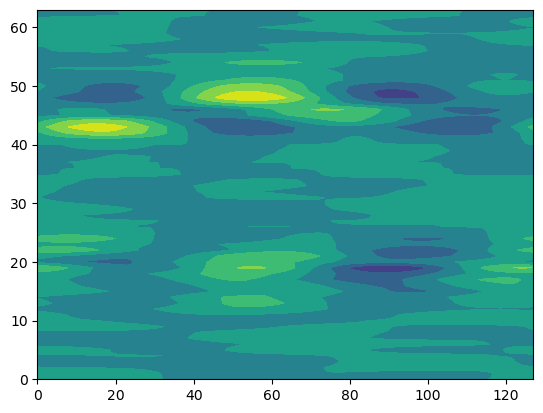

In [63]:
if 'z_wn1' in globals():
    del z_wn1
if 'prec_wn1' in globals():
    del prec_wn1

prec_wn1 = fft_filtering(prec,dim=2,wave_numbers=[1,2])
z_wn1    = fft_filtering(z,dim=2,wave_numbers=[1,2,3,4,5,6])

plt.figure()
plt.contourf(prec_wn1[500,:,:])


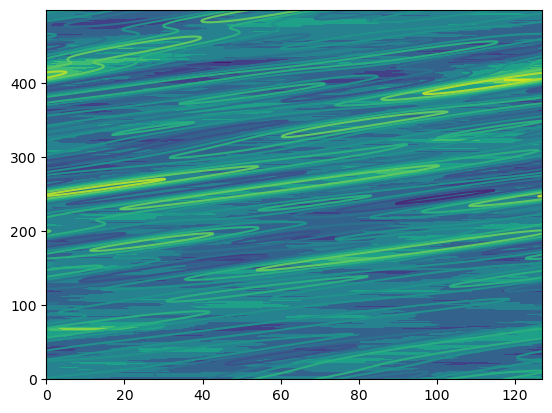

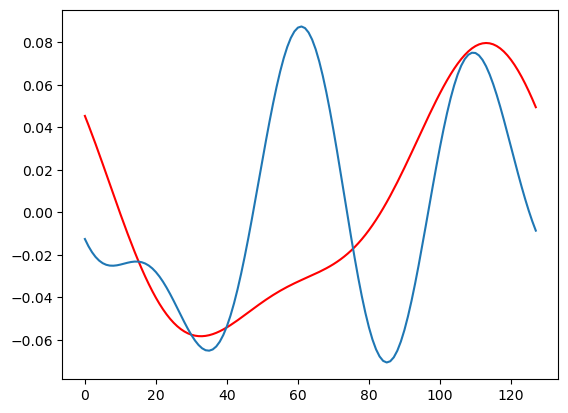

In [64]:
plt.figure()
plt.contourf(prec_wn1[500:1000,lat_cond,:].mean(axis=1))
plt.contour(prec_recon[500:1000,:,:].mean(axis=1))

plt.figure()
plt.plot(prec_wn1[500,lat_cond,:].mean(axis=0),'r')
plt.plot(prec_recon[500,:,:].mean(axis=0))

In [759]:
%%ai chatgpt 
how to deepcopy a array in python

```python
import copy

# Original array
original_arr = [1, 2, 3, 4, 5]

# Deepcopy of the array
deepcopy_arr = copy.deepcopy(original_arr)

print(deepcopy_arr)
```

In [106]:
import copy
# rolling the data and make composite all over again 
variables_to_delete = ['tmp','tmp_z','tmp_prec_wn1','tmp_z_wn1']

for variable in variables_to_delete:
    if variable in globals():
        del globals()[variable]
    
tmp              = prec_recon.mean(axis=1)[:,:]
tmp_z            = copy.deepcopy(z[:,:,:].reshape([78000*64,128]))
tmp_prec_wn1     = copy.deepcopy(prec_wn1[:,:,:].reshape([78000*64,128]))
tmp_z_wn1        = copy.deepcopy(z_wn1[:,:,:].reshape([78000*64,128]))

posi_time,posi_x = np.where(tmp == np.max(tmp,axis=1)[:,np.newaxis])
lag = 5*4 
for i in range(tmp.shape[0]):
    if i >= (78000-lag):
        pass
    else:
        tmp[(i+lag),:]                        = np.roll(tmp[(i+lag),:], 64-posi_x[i])
        tmp_z[(i+lag)*64:((i+lag)+1)*64,:]          = np.roll(tmp_z[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
        tmp_prec_wn1[(i+lag)*64:((i+lag)+1)*64,:]   = np.roll(tmp_prec_wn1[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
        tmp_z_wn1[(i+lag)*64:((i+lag)+1)*64,:]      = np.roll(tmp_z_wn1[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])

50


<Figure size 640x480 with 0 Axes>

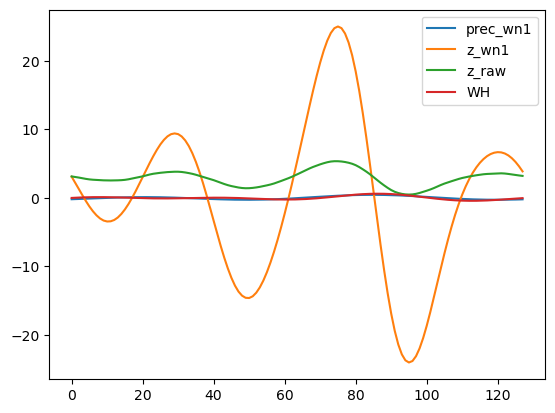

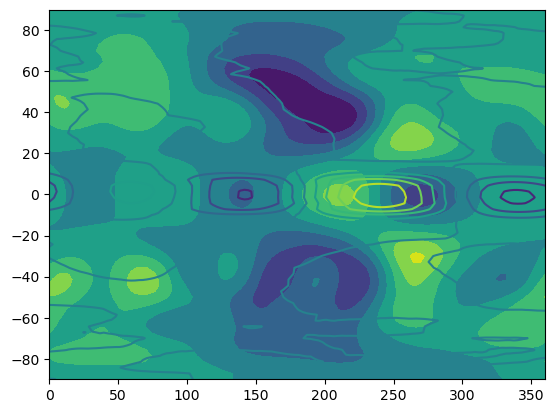

In [107]:
tmp_prec_wn1 = tmp_prec_wn1.reshape([78000,64,128])
tmp_z_wn1    = tmp_z_wn1.reshape([78000,64,128])
tmp_z        = tmp_z.reshape([78000,64,128])
plt.figure()

plt.figure()
plt.plot(tmp_prec_wn1[:,lat_cond,:].mean(axis=(0,1))*10,label='prec_wn1')
plt.plot(tmp_z_wn1[:,lat_cond,:].mean(axis=(0,1))*10,label='z_wn1')
plt.plot(tmp_z[:,lat_cond,:].mean(axis=(0,1)),label='z_raw')
plt.plot(tmp[:,:].mean(axis=(0))*10,label='WH')
plt.legend()

x = np.linspace(0,360,128)
y = np.linspace(-90,90,64)
xx, yy = np.meshgrid(x,y)

plt.figure()
plt.contourf(xx,yy,tmp_z_wn1[:,:,:].mean(axis=(0))-tmp_z_wn1[:,:,:].mean(axis=(0,2))[:,np.newaxis])
plt.contour(xx,yy,tmp_prec_wn1[:,:,:].mean(axis=(0)))
#plt.ylim([-30,30])
print(PR)

In [67]:
def Cal_EOF_PC_for_barotropic(input_data):
    from EOF import EOF
    # input : (time, y)
    
    # Perform latitude weighting
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[1]))))

    # Initialize an EOF instance with weighted input data
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    print("n_component:", n_component)
    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="1D")
    
    # Compute EOFs and PCs
    eof_instance.get()
    
    # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]

    # Normalize PCs and EOFs
    PC1_norm, PC2_norm = PC1 / PC1.std(), PC2 / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
    return EOF1_norm, PC1_norm, EOF2_norm, PC2_norm

EOF1_all, EOF2_all = np.zeros((6, 32)), np.zeros((6, 32))
PC1_all , PC2_all  = np.zeros((6, 19500)), np.zeros((6, 19500))

EOF1_6hourly_all, EOF2_6hourly_all = np.zeros((6, 32)), np.zeros((6, 32))
PC1_6hourly_all , PC2_6hourly_all  = np.zeros((6, 19500*4)), np.zeros((6, 19500*4))


aa = 0
for PR in [0, 10, 20, 30, 40, 50]:
        file_path = f"/data92/PeterChang/1014_preprocessing/PR{PR}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"        
        with h5py.File(file_path, 'r') as U_file:
            print(U_file.keys())
            u = U_file["u"][:, :]  # Barotropic u
        u_daily = np.mean(u.reshape(-1,4,64), axis=1);print(u_daily.shape)
        EOF1_6hourly_all[aa], PC1_6hourly_all[aa], EOF2_6hourly_all[aa], PC2_6hourly_all[aa] = Cal_EOF_PC_for_barotropic(u[:,32:])
        # EOF1_all[aa], PC1_all[aa], EOF2_all[aa], PC2_all[aa] = Cal_EOF_PC_for_barotropic(u_all[:,:,32:,:].mean(axis=(1,3)))
        aa += 1

<KeysViewHDF5 ['u']>
(19500, 64)
n_component: 32
<KeysViewHDF5 ['u']>
(19500, 64)
n_component: 32
<KeysViewHDF5 ['u']>
(19500, 64)
n_component: 32
<KeysViewHDF5 ['u']>
(19500, 64)
n_component: 32
<KeysViewHDF5 ['u']>
(19500, 64)
n_component: 32
<KeysViewHDF5 ['u']>
(19500, 64)
n_component: 32


In [87]:
PC1_6hourly = PC1_6hourly_all[0]

In [88]:
time_idx_positive = np.where(PC1_6hourly > 1 * PC1_6hourly.std())[0]
time_idx_negative = np.where(PC1_6hourly < -1 * PC1_6hourly.std())[0]

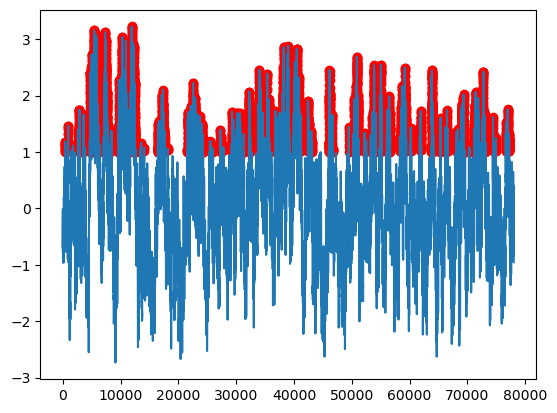

In [89]:
plt.figure()
plt.plot(PC1_6hourly)
plt.scatter(time_idx_positive,PC1_6hourly[time_idx_positive], color="Red")

In [90]:
import copy
# rolling the data and make composite all over again 
variables_to_delete = ['tmp','tmp_z','tmp_prec_wn1','tmp_z_wn1']

for variable in variables_to_delete:
    if variable in globals():
        del globals()[variable]


# lag 5~20 day

In [91]:
import numpy as np
import copy
import matplotlib.pyplot as plt

# Define the lag range (from 5 to 20 days in 6-hour intervals)
lag_range = range(5 * 4, 20 * 4)

# Set up variables to store lagged means
variables_to_delete = ['tmp', 'tmp_z', 'tmp_prec_wn1', 'tmp_z_wn1']
for variable in variables_to_delete:
    if variable in globals():
        del globals()[variable]
        

    
# Set up positive lagged indices and define the selection length
for aa, lag in enumerate(lag_range):

    time_idx_positive_lag = time_idx_positive + lag
    sel_idx_length = len(time_idx_positive_lag)
    
    # Initialize the data arrays
    tmp = prec_recon.mean(axis=1)[time_idx_positive_lag, :]
    tmp_z = copy.deepcopy(z[time_idx_positive_lag, :, :].reshape([sel_idx_length * 64, 128]))
    tmp_prec_wn1 = copy.deepcopy(prec_wn1[time_idx_positive_lag, :, :].reshape([sel_idx_length * 64, 128]))
    tmp_z_wn1 = copy.deepcopy(z_wn1[time_idx_positive_lag, :, :].reshape([sel_idx_length * 64, 128]))
    if aa == 0:
        # Accumulators for lagged mean results
        tmp_accum = np.zeros_like(tmp)
        tmp_z_accum = np.zeros_like(tmp_z)
        tmp_prec_wn1_accum = np.zeros_like(tmp_prec_wn1)
        tmp_z_wn1_accum = np.zeros_like(tmp_z_wn1)
    # Identify position of max values for alignment
    posi_time, posi_x = np.where(tmp == np.max(tmp, axis=1)[:, np.newaxis])
    
    # Apply rolling over specified lag range and accumulate results
    for i in range(tmp.shape[0]):
        tmp_accum[i, :] += np.roll(tmp[i, :], 64 - posi_x[i])
        tmp_z_accum[i * 64:(i + 1) * 64, :] += np.roll(tmp_z[i * 64:(i + 1) * 64, :], 64 - posi_x[i])
        tmp_prec_wn1_accum[i * 64:(i + 1) * 64, :] += np.roll(tmp_prec_wn1[i * 64:(i + 1) * 64, :], 64 - posi_x[i])
        tmp_z_wn1_accum[i * 64:(i + 1) * 64, :] += np.roll(tmp_z_wn1[i * 64:(i + 1) * 64, :], 64 - posi_x[i])

# Take the mean over the accumulated results
tmp_mean = tmp_accum / len(lag_range)
tmp_z_mean = tmp_z_accum / len(lag_range)
tmp_prec_wn1_mean = tmp_prec_wn1_accum / len(lag_range)
tmp_z_wn1_mean = tmp_z_wn1_accum / len(lag_range)



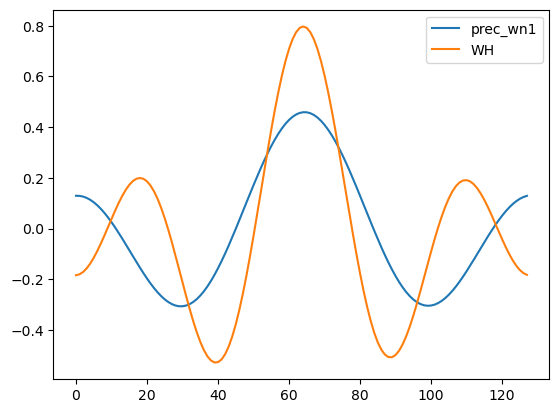

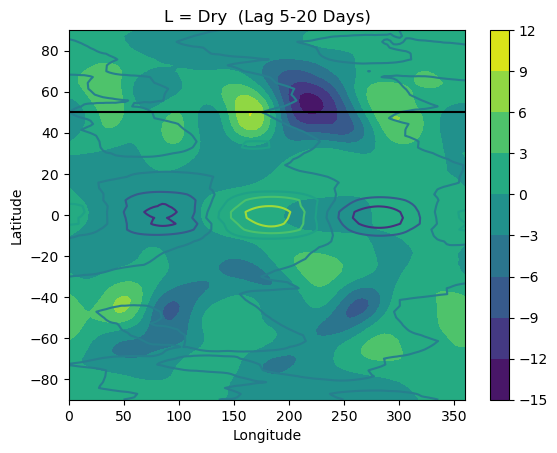

In [92]:
# Reshape lagged arrays for plotting
tmp_prec_wn1_mean = tmp_prec_wn1_mean.reshape([sel_idx_length, 64, 128])
tmp_z_wn1_mean    = tmp_z_wn1_mean.reshape([sel_idx_length, 64, 128])
tmp_z_mean        = tmp_z_mean.reshape([sel_idx_length,64,128])

# Plot line plot for lagged mean of selected variables
plt.figure()
plt.plot(tmp_prec_wn1_mean[:, lat_cond, :].mean(axis=(0, 1)) * 10, label='prec_wn1')
# plt.plot(tmp_z_wn1_mean[:, lat_cond, :].mean(axis=(0, 1)) * 10, label='z_wn1')
# plt.plot(tmp_z_mean[:, lat_cond, :].mean(axis=(0, 1)), label='z_raw')
plt.plot(tmp_mean[:, :].mean(axis=0) * 10, label='WH')
plt.legend()

# Plot contour for spatial distribution
x = np.linspace(0, 360, 128)
y = np.linspace(-90, 90, 64)
xx, yy = np.meshgrid(x, y)

plt.figure()
CS = plt.contourf(xx, yy, tmp_z_wn1_mean[:, :, :].mean(axis=0) - tmp_z_wn1_mean[:, :, :].mean(axis=(0, 2))[:, np.newaxis])
plt.contour(xx, yy, tmp_prec_wn1_mean[:, :, :].mean(axis=0))
plt.title("L = Dry  (Lag 5-20 Days)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.hlines(y=50, xmin=0, xmax=360, color="Black")

plt.colorbar(CS)
plt.show()

# lag 90~100 day

In [29]:
prec_recon.shape

(78000, 10, 128)

In [93]:
import numpy as np
import copy
import matplotlib.pyplot as plt

# Define the lag range (from 90 to 100 days in 6-hour intervals)
lag_range = range(90 * 4, 100 * 4)

# Set up variables to store lagged means
variables_to_delete = ['tmp', 'tmp_z', 'tmp_prec_wn1', 'tmp_z_wn1']
for variable in variables_to_delete:
    if variable in globals():
        del globals()[variable]
        
# Filter `time_idx_positive` to ensure all indices are within bounds
time_idx_positive = time_idx_positive[time_idx_positive < 78000]
sel_idx_length = len(time_idx_positive)

# Initialize accumulators for lagged mean results
tmp_accum = np.zeros((sel_idx_length, 128))
tmp_z_accum = np.zeros((sel_idx_length * 64, 128))
tmp_prec_wn1_accum = np.zeros((sel_idx_length * 64, 128))
tmp_z_wn1_accum = np.zeros((sel_idx_length * 64, 128))

# Apply rolling over specified lag range and accumulate results
for lag in lag_range:
    time_idx_positive_lag = time_idx_positive + lag
    time_idx_positive_lag = time_idx_positive_lag[time_idx_positive_lag < 78000]
    sel_idx_length = len(time_idx_positive_lag)
    
    
    # Initialize temporary data arrays
    tmp = prec_recon.mean(axis=1)[time_idx_positive_lag, :]
    tmp_z = z[time_idx_positive_lag, :, :].reshape([sel_idx_length * 64, 128])
    tmp_prec_wn1 = prec_wn1[time_idx_positive_lag, :, :].reshape([sel_idx_length * 64, 128])
    tmp_z_wn1 = z_wn1[time_idx_positive_lag, :, :].reshape([sel_idx_length * 64, 128])

    # Identify position of max values for alignment
    posi_time, posi_x = np.where(tmp == np.max(tmp, axis=1)[:, np.newaxis])
    
    for i in range(tmp.shape[0]):
        tmp_accum[i, :] += np.roll(tmp[i, :], 64 - posi_x[i])
        tmp_z_accum[i * 64:(i + 1) * 64, :] += np.roll(tmp_z[i * 64:(i + 1) * 64, :], 64 - posi_x[i])
        tmp_prec_wn1_accum[i * 64:(i + 1) * 64, :] += np.roll(tmp_prec_wn1[i * 64:(i + 1) * 64, :], 64 - posi_x[i])
        tmp_z_wn1_accum[i * 64:(i + 1) * 64, :] += np.roll(tmp_z_wn1[i * 64:(i + 1) * 64, :], 64 - posi_x[i])

# Print to verify dimensions
print("Final dimensions:")
print("tmp_prec_wn1:", tmp_prec_wn1.shape)
print("tmp_prec_wn1_accum:", tmp_prec_wn1_accum.shape)
print("tmp_accum:", tmp_accum.shape)


Final dimensions:
tmp_prec_wn1: (819072, 128)
tmp_prec_wn1_accum: (819072, 128)
tmp_accum: (12798, 128)


In [94]:
print(tmp_prec_wn1.shape)
print(time_idx_positive_lag.shape)
print(tmp_prec_wn1_accum.shape)

tmp_prec_wn1_accum.shape[0] / 64
tmp_prec_wn1_accum.shape

(819072, 128)
(12798,)
(819072, 128)


(819072, 128)

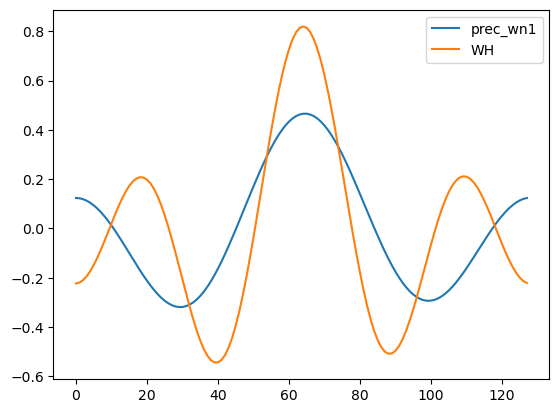

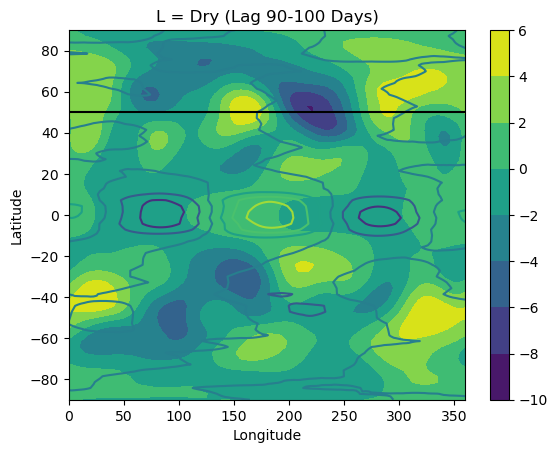

In [95]:
# # Take the mean over the accumulated results
# tmp_z_mean = tmp_z_accum / len(lag_range)
# tmp_prec_wn1_mean = tmp_prec_wn1_accum / len(lag_range)
# tmp_z_wn1_mean = tmp_z_wn1_accum / len(lag_range)

day = int(tmp_prec_wn1_accum.shape[0] / 64)
# Reshape lagged arrays for plotting
tmp_prec_wn1_90_100_mean = tmp_prec_wn1_accum.reshape([day, 64, 128])
tmp_z_wn1_90_100_mean    = tmp_z_wn1_accum.reshape([day, 64, 128])
tmp_z_90_100_mean        = tmp_z_accum.reshape([day,64,128])

tmp_90_100_mean = tmp_accum / len(lag_range)
tmp_prec_wn1_90_100_mean /= len(lag_range)
tmp_z_wn1_90_100_mean    /= len(lag_range)
tmp_z_90_100_mean        /= len(lag_range)


# Plot line plot for lagged mean of selected variables
plt.figure()
plt.plot(tmp_prec_wn1_90_100_mean[:, lat_cond, :].mean(axis=(0, 1)) * 10, label='prec_wn1')
# plt.plot(tmp_z_wn1_mean[:, lat_cond, :].mean(axis=(0, 1)) * 10, label='z_wn1')
# plt.plot(tmp_z_mean[:, lat_cond, :].mean(axis=(0, 1)), label='z_raw')
plt.plot(tmp_90_100_mean[:, :].mean(axis=0) * 10, label='WH')
plt.legend()

# Plot contour for spatial distribution
x = np.linspace(0, 360, 128)
y = np.linspace(-90, 90, 64)
xx, yy = np.meshgrid(x, y)

plt.figure()
CS = plt.contourf(xx, yy, tmp_z_wn1_90_100_mean[:, :, :].mean(axis=0) - tmp_z_wn1_90_100_mean[:, :, :].mean(axis=(0, 2))[:, np.newaxis])
plt.contour(xx, yy, tmp_prec_wn1_90_100_mean[:, :, :].mean(axis=0))
plt.title("L = Dry (Lag 90-100 Days)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.hlines(y=50, xmin=0, xmax=360, color="Black")

plt.colorbar(CS)
plt.show()

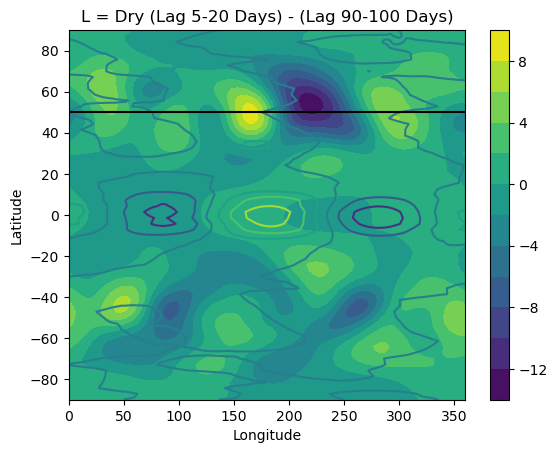

In [85]:
plt.figure()
CS = plt.contourf(xx, yy, (tmp_z_wn1_mean[:, :, :].mean(axis=0) - tmp_z_wn1_mean[:, :, :].mean(axis=(0, 2))[:, np.newaxis]) - (tmp_z_wn1_90_100_mean[:, :, :].mean(axis=0) - tmp_z_wn1_90_100_mean[:, :, :].mean(axis=(0, 2))[:, np.newaxis]), levels=11)
plt.contour(xx, yy, tmp_prec_wn1_mean[:, :, :].mean(axis=0))
plt.title("L = Dry (Lag 5-20 Days) - (Lag 90-100 Days)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.hlines(y=50, xmin=0, xmax=360, color="Black")
plt.colorbar(CS)
plt.show()